# Module 2, Extra exercises

Find below random exercises to practice more with the sorting and the data structures we have seen during the practical lessons. Solutions will be provided in a few days.

## Class Definitions (BinaryTree and DiGraphLL)
These classes are provided for the exercises.

In [3]:
# BinaryTree class
class BinaryTree:
    def __init__(self, value):
        self.__data = value
        self.__right = None
        self.__left = None
        self.__parent = None

    def getValue(self):
        return self.__data
    def setValue(self, newValue):
        self.__data = newValue

    def getParent(self):
        return self.__parent
    def setParent(self, tree):
        self.__parent = tree

    def getRight(self):
        return self.__right
    def getLeft(self):
        return self.__left

    def insertRight(self, tree):
        if self.__right == None:
            self.__right = tree
            tree.setParent(self)

    def insertLeft(self, tree):
        if self.__left == None:
            self.__left = tree
            tree.setParent(self)

    def deleteRight(self):
        self.__right = None

    def deleteLeft(self):
        self.__left = None

def printTree(root):
    cur = root
    #each element is a node and a depth
    #depth is used to format prints (with tabs)
    nodes = [(cur,0)]
    tabs = ""
    lev = 0
    while len(nodes) >0:
        cur, lev = nodes.pop(-1)
        #print("{}{}".format("\t"*lev, cur.getValue()))
        if cur.getRight() != None:
            print ("{}{} (r)-> {}".format("\t"*lev,
                                          cur.getValue(),
                                          cur.getRight().getValue()))
            nodes.append((cur.getRight(), lev+1))
        if cur.getLeft() != None:
            print ("{}{} (l)-> {}".format("\t"*lev,
                                          cur.getValue(),
                                          cur.getLeft().getValue()))
            nodes.append((cur.getLeft(), lev+1))


In [9]:
# Directed graph class
class DiGraphLL:
    def __init__(self):
        self.nodes = dict()

    def insertNode(self, node):
        test = self.nodes.get(node, None)

        if test == None:
            self.nodes[node] = {}

    def insertEdge(self, node1, node2, weight):
        test = self.nodes.get(node1, None)
        test1 = self.nodes.get(node2, None)
        if test != None and test1 != None:
            test = self.nodes[node1].get(node2, None)
            if test != None:
                exStr= "Edge {} --> {} already existing.".format(node1,node2)
                raise Exception(exStr)
            else:
                self.nodes[node1][node2] = weight


    def __len__(self):
        return len(self.nodes)

    def nodes(self):
        return list(self.nodes.keys())

    def graph(self):
        return self.nodes

    def __str__(self):
        ret = ""
        for n in self.nodes:
            for edge in self.nodes[n]:

                ret += "{} -- {} --> {}\n".format(str(n),
                                                  str(self.nodes[n][edge]),
                                                  str(edge))
        return ret
    

### Exercise 1 — Count the Number of Nodes in a Tree

The goal of this exercise is to understand how to traverse a binary tree both recursively and iteratively. You are asked to implement a method in the BinaryTree class that returns the total number of nodes in the subtree rooted at the current node using recursion. Then, implement a second version that computes the same value without using recursion, relying instead on an explicit stack or queue. Both methods should return the same result when tested.

Implement recursive and iterative versions:

```
def countNodes(self):
    pass

def countNodes_iter(self):
    pass
```

Test if you implemented it right with the code below:

In [5]:
# Autograding test for Exercise 1
root = BinaryTree(0)
a = BinaryTree(1); b = BinaryTree(2)
root.insertLeft(a); root.insertRight(b)

try:
    assert root.countNodes() == 3
    assert root.countNodes_iter() == 3
    print('Exercise 1 passed')
except Exception as e:
    print('Exercise 1 failed:', e)

Exercise 1 failed: 'BinaryTree' object has no attribute 'countNodes'


### Exercise 2 — Check Whether a Value Exists in the Tree

This exercise focuses on searching within a binary tree. You should implement a method that returns True if a given value exists anywhere in the tree, using recursion to traverse the nodes. Then, create a second version that performs the same search without recursion, using an explicit stack or queue to explore the tree. Both versions should correctly identify whether the value is present, even if every node needs to be checked.

```
def contains(self, value):
    pass

def contains_iter(self, value):
    pass

```

Test the output with the code below:

In [ ]:
root = BinaryTree(1)
a = BinaryTree(2)
b = BinaryTree(3)
root.insertLeft(a)
root.insertRight(b)

print(root.contains(2))       # Expected output: True
print(root.contains_iter(5))  # Expected output: False


### Exercise 3 — Compute the Height of the Tree

Compute the height of a binary tree where a leaf node has height one and an empty subtree has height zero. Implement a recursive method that calculates the height and an iterative method using a stack or queue to track node depth. Both methods should return the same height.

Example:
A tree with a root node and two children has height 2. Calling the method on the root node should return 2.

Template for your code:

```
def height(self):
    pass

def height_iter(self):
    pass
```

Example check:

In [ ]:
root = BinaryTree(0)
a = BinaryTree(1)
b = BinaryTree(2)
root.insertLeft(a)
root.insertRight(b)

print(root.height())       # Expected output: 2
print(root.height_iter())  # Expected output: 2

### Exercise 4.1 — Check if a node has a self edge in a Graph

Consider the DiGraphLL class provided above.
Use this code below to generate the following graph:

![Screenshot from 2025-12-05 11-47-47.png](<attachment:Screenshot from 2025-12-05 11-47-47.png>)


Code:
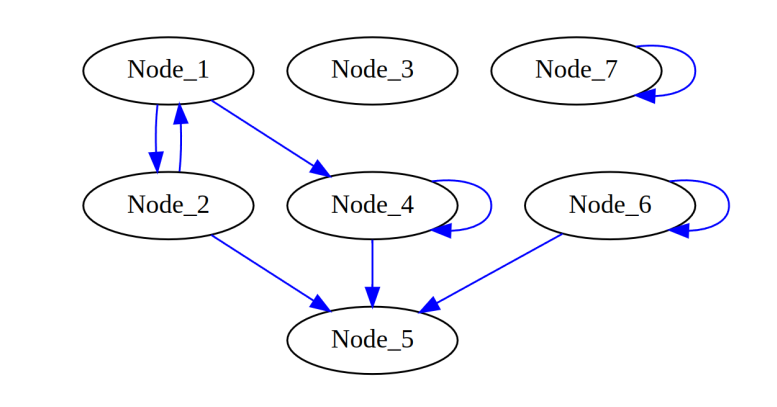

In [10]:
G = DiGraphLL()
for i in range(7):
    n = "Node_{}".format(i+1)
    G.insertNode(n)

G.insertEdge("Node_2", "Node_1", 7)
G.insertEdge("Node_1", "Node_2", 2)
G.insertEdge("Node_1", "Node_4", 5)
G.insertEdge("Node_2", "Node_5", 6)
G.insertEdge("Node_6", "Node_5", 3)
G.insertEdge("Node_4", "Node_5", 15)
G.insertEdge("Node_6", "Node_6", 2)
G.insertEdge("Node_7", "Node_7", 4)
G.insertEdge("Node_4", "Node_4", 4)

print("Size is: {}".format(len(G)))
print("Nodes: {}".format(G.nodes))

Size is: 7
Nodes: {'Node_1': {'Node_2': 2, 'Node_4': 5}, 'Node_2': {'Node_1': 7, 'Node_5': 6}, 'Node_3': {}, 'Node_4': {'Node_5': 15, 'Node_4': 4}, 'Node_5': {}, 'Node_6': {'Node_5': 3, 'Node_6': 2}, 'Node_7': {'Node_7': 4}}


Implement a method called *checkSelfEdge()* in the DiGraphLL class that takes a node as input and returns True if the node has an edge pointing to itself, and False otherwise. Make sure to first verify that the node exists in the graph.

Hint: Use the adjacency dictionary to determine if the node has an outgoing edge to itself.

```
def checkSelfEdge(self, node):
    pass

```

In [ ]:

print("Check for self edge --> \n")
print("Node_10:")
print(G.checkSelfEdge("Node_10")) #should return "node not found"
print("Node_2:")
print(G.checkSelfEdge("Node_2")) #should return False
print("Node_6:")
print(G.checkSelfEdge("Node_6")) #should return True
print("Node_7:") 
print(G.checkSelfEdge("Node_7")) #should return True
    

### Exercise 4.2 — Check if a node is isolated (no edges with other nodes)

Implement a method called *isolatedNodes()* in the DiGraphLL class that returns a list of all nodes that are completely isolated from the graph. A node is considered isolated if it has no incoming or outgoing edges to other nodes. Self-loops (edges from the node to itself) should not count as connections: nodes with self-loops are still considered isolated.

```
def isolatedNodes(self):
    pass

```

Test with:

In [ ]:
print("Isolated nodes:\n")
print(G.isolatedNodes())

assert(G.isolatedNodes() == ['Node_3', 'Node_7'])